<a href="https://colab.research.google.com/github/Vitoriabbc1/analiseinunda-o_rj/blob/main/analise_inunda%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- 📐 NOVA MATRIZ DE CRITICIDADE: TIPOLOGIA GERAL VS RISCO (KM) ---
classe             Alta   Baixa   Média
tipologia_geral                        
ARROIO             5.43    2.73   10.10
CANAL             48.85  168.09   98.06
RIO              139.03  460.93  272.67
VALA               9.04   34.83    5.91
VALÃO              0.00   13.98    0.99


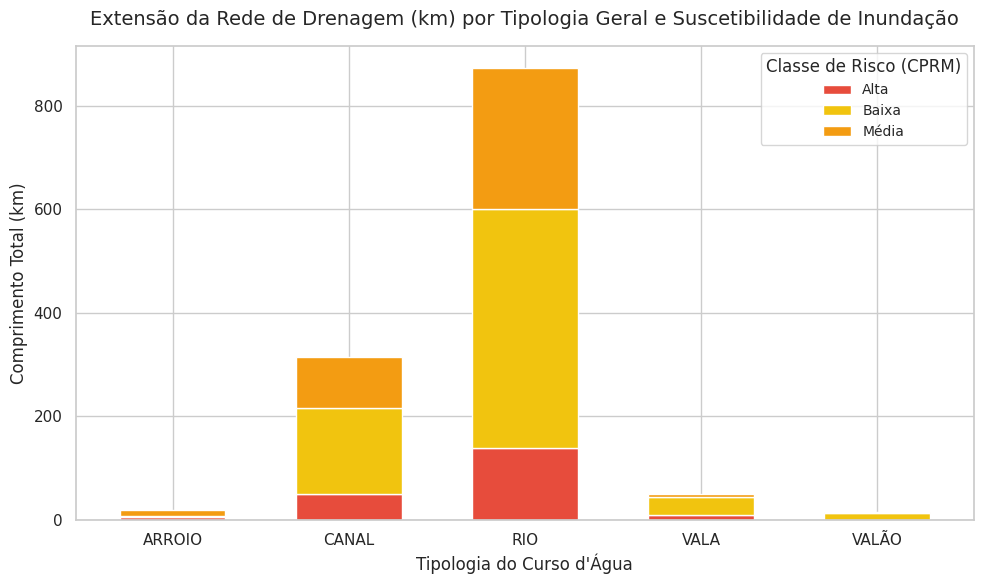

In [10]:
# 1. Carregar os dados (mantendo o caminho que deu certo)
caminho_drive = "/content/tabela_inun.csv"
df = pd.read_csv(caminho_drive)
# 2. Calcular o comprimento em Quilômetros
df['comprimento_km'] = df['compriment'] / 1000

# 🌟 O TRUQUE DE MESTRE: Pegar apenas a primeira palavra de 'nom_h' para criar as Tipologias gerais
# Convertemos para texto, pegamos a primeira palavra com split() e deixamos em maiúsculo
df['tipologia_geral'] = df['nom_hidro'].astype(str).str.split().str[0].str.upper()

# Vamos limpar nomes estranhos ou vazios que possam surgir (opcional)
df['tipologia_geral'] = df['tipologia_geral'].replace({'AF.': 'RIO', 'VALAO': 'VALÃO', 'NAN': 'NÃO IDENTIFICADO'})

print("--- 📐 NOVA MATRIZ DE CRITICIDADE: TIPOLOGIA GERAL VS RISCO (KM) ---")
# Agora agrupamos pela nova coluna 'tipologia_geral'
matriz_critica = pd.crosstab(
    index=df['tipologia_geral'],
    columns=df['classe'],
    values=df['comprimento_km'],
    aggfunc='sum'
).fillna(0).round(2)

# Filtrar para mostrar apenas as principais tipologias e não poluir o gráfico
principais_tipos = ['RIO', 'CANAL', 'VALA', 'VALÃO', 'ARROIO', 'CORREGO''RIACHO' ]
matriz_critica = matriz_critica.loc[matriz_critica.index.isin(principais_tipos)]

print(matriz_critica)

# 3. GERAR O GRÁFICO LIMPO E PROFISSIONAL
sns.set_theme(style="whitegrid")

# Ajustando a ordem das cores para bater com as colunas da CPRM que apareceram (Alta, Baixa, Média)
# Verifique a ordem exata das colunas no print da sua matriz para ordenar as cores:
cores_risco = ["#e74c3c", "#f1c40f", "#f39c12"] # Vermelho (Alta), Amarelo (Média), Laranja/Verde (Baixa)

ax = matriz_critica.plot(
    kind="bar",
    stacked=True,
    color=cores_risco,
    figsize=(10, 6),
    width=0.6
)

plt.title("Extensão da Rede de Drenagem (km) por Tipologia Geral e Suscetibilidade de Inundação", fontsize=14, pad=15)
plt.xlabel("Tipologia do Curso d'Água", fontsize=12)
plt.ylabel("Comprimento Total (km)", fontsize=12)
plt.xticks(rotation=0, fontsize=11) # Rotação 0 para os nomes ficarem retos e fáceis de ler!
plt.legend(title="Classe de Risco (CPRM)", fontsize=10)
plt.tight_layout()

# Salvar a imagem perfeita para o Notion
plt.savefig("grafico_suscetibilidade_limpo.png", dpi=300)
plt.show()




--- 🏆 TOP 10 BAIRROS COM MAIOR EXTENSÃO DE REDE DE DRENAGEM EM RISCO ALTO (KM) ---
classe              Alta  Média   Baixa
nom_bairro                             
Bangu              18.97   0.87   27.08
Alto da Boa Vista   3.48   0.00   44.58
Barra da Tijuca     3.43   9.30    0.00
Jacarepaguá         3.20  15.62  107.95
Cosme Velho         3.15   0.30    0.00
Andaraí             3.05   0.09    0.00
Maré                2.90   1.38    0.00
Caju                2.53   0.00    0.00
Santa Cruz          2.44   3.87  185.36
Gericinó            2.43   0.00    0.00


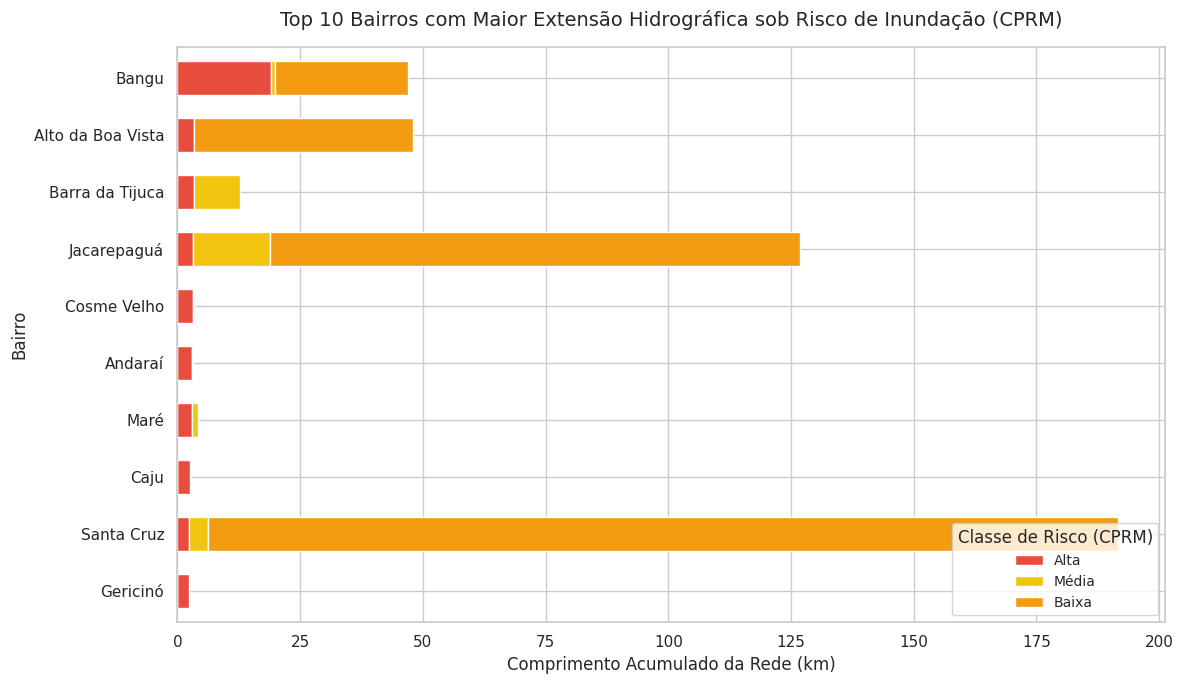

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados (usando o DataFrame que você já tem na memória)
# Se precisar ler o arquivo de novo, descomente a linha abaixo:
# df = pd.read_csv("/inundac_hidrografia.csv")

# Garantir que o comprimento esteja em quilômetros
df['comprimento_km'] = df['compriment'] / 1000

# 2. Criação de tabela cruzada: Bairros vs. Classe de Risco
# Somar comprimento em km de cada trecho dentro de cada bairro
matriz_bairros = pd.crosstab(
    index=df['nom_bairro'],
    columns=df['classe'],
    values=df['comprimento_km'],
    aggfunc='sum'
).fillna(0)

# 3. Filtrando e ordenando pelo risco "Alta" para pegar o Top 10 bairros mais críticos
top10_criticos = matriz_bairros.sort_values(by='Alta', ascending=False).head(10)

print("--- 🏆 TOP 10 BAIRROS COM MAIOR EXTENSÃO DE REDE DE DRENAGEM EM RISCO ALTO (KM) ---")
print(top10_criticos[['Alta', 'Média', 'Baixa']].round(2))

# 4. Configuração do layout do gráfico de barras horizontais
sns.set_theme(style="whitegrid")

# Definição das cores para manter a identidade visual do projeto (Alta = Vermelho, Média = Laranja, Baixa = Amarelo)
cores_risco = ["#e74c3c", "#f1c40f", "#f39c12"]

# Gráfico de barras horizontais empilhadas (kind="barh")
ax = top10_criticos[['Alta', 'Média', 'Baixa']].iloc[::-1].plot(
    kind="barh",
    stacked=True,
    color=cores_risco,
    figsize=(12, 7),
    width=0.6
)

#Títulos e rótulos refinados
plt.title("Top 10 Bairros com Maior Extensão Hidrográfica sob Risco de Inundação (CPRM)", fontsize=14, pad=15)
plt.xlabel("Comprimento Acumulado da Rede (km)", fontsize=12)
plt.ylabel("Bairro", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Classe de Risco (CPRM)", loc="lower right", fontsize=10)
plt.tight_layout()

# 5. Salvando imagem para a sua nova pasta do repositório!
plt.savefig("top10_bairros_criticos.png", dpi=300)
plt.show()





--- 🕳️ MATRIZ: RIOS COBERTOS VS CÉU ABERTO (KM) ---
classe                   Alta    Baixa   Média
status_coberto                                
Céu Aberto             234.78  1040.61  441.58
Subterrâneo / Coberto   30.19    35.68   49.71


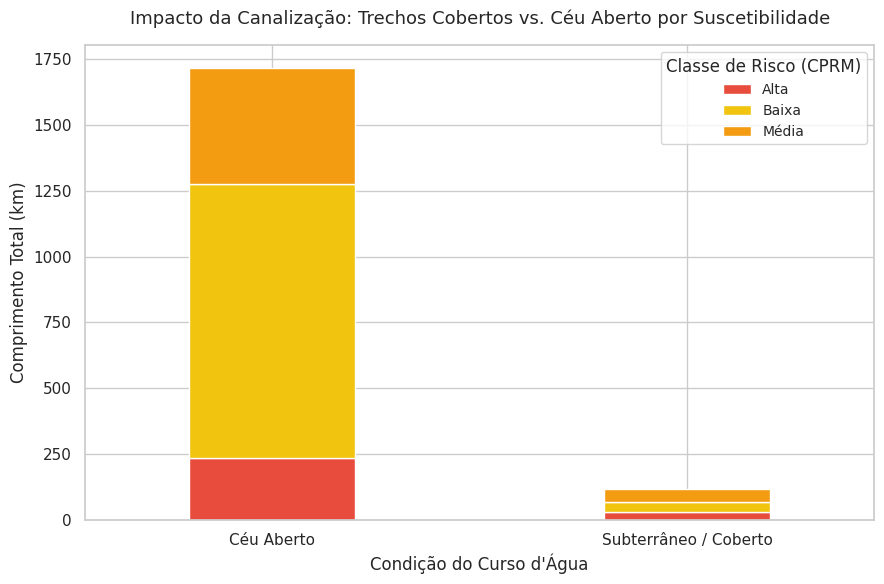

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados (usando seu DataFrame na memória)
# df = pd.read_csv("/inundac_hidrografia.csv")

# Comprimento em quilômetros
df['comprimento_km'] = df['compriment'] / 1000

# Padronizar a coluna 'coberto' para ficar bonita no gráfico
df['status_coberto'] = df['coberto'].map({'S': 'Subterrâneo / Coberto', 'N': 'Céu Aberto'})

# 2. Criar a tabela cruzada: Status do Curso d'Água vs. Classe de Risco
matriz_cobertos = pd.crosstab(
    index=df['status_coberto'],
    columns=df['classe'],
    values=df['comprimento_km'],
    aggfunc='sum'
).fillna(0).round(2)

print("--- 🕳️ MATRIZ: RIOS COBERTOS VS CÉU ABERTO (KM) ---")
print(matriz_cobertos)

# 3. Gráfico de barras empilhadas proporcional
sns.set_theme(style="whitegrid")
cores_risco = ["#e74c3c", "#f1c40f", "#f39c12"]

ax = matriz_cobertos.plot(
    kind="bar",
    stacked=True,
    color=cores_risco,
    figsize=(9, 6),
    width=0.4
)

# Ajustes estéticos
plt.title("Impacto da Canalização: Trechos Cobertos vs. Céu Aberto por Suscetibilidade", fontsize=13, pad=15)
plt.xlabel("Condição do Curso d'Água", fontsize=12)
plt.ylabel("Comprimento Total (km)", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Classe de Risco (CPRM)", fontsize=10)
plt.tight_layout()

# 4. Salvar a imagem para a pasta assets
plt.savefig("canais_cobertos_vs_ceu_aberto.png", dpi=300)
plt.show()